Last edited: 1/30/2026, 2:35 PM CST
# GEV Heat Waves Analysis

ERA 5.

In [1]:
# import base packages for data analysis
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import xesmf as xe

from scipy.stats import genextreme, describe
from astropy.stats import kuiper, kuiper_two

from config import DATA_ROOT

# import custom stuff
from ambpy.plotutils import make_figure_filename
# plt.style.use('ambpy')

# set random attributes
np.random.seed(4)

save_figs = False

In [20]:
ds_max = xr.open_dataset(DATA_ROOT / 'ERA5' / 'era5_t2m_annual_max_1deg.nc')
ds_min = xr.open_dataset(DATA_ROOT / 'ERA5' / 'era5_t2m_annual_min_1deg.nc')
ds_mean = xr.open_dataset(DATA_ROOT / 'ERA5' / 'era5_t2m_annual_mean_1deg.nc')
land_mask = xr.open_dataset(DATA_ROOT / 'ERA5' / 'era5_land_mask.nc')

# ds_max.sel(year=slice(1979, 2024))

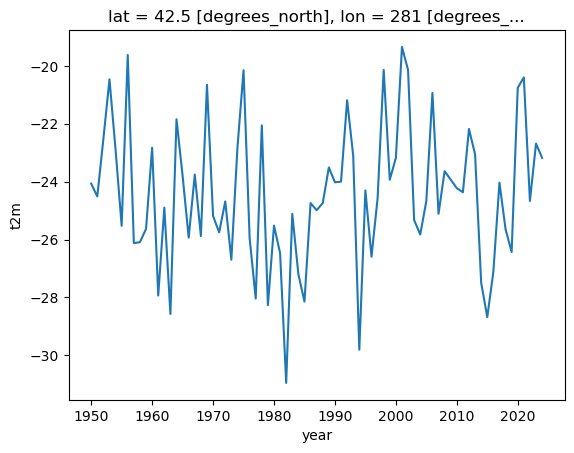

In [29]:
(ds_min - ds_mean).sel(lat=buf_lat, lon=buf_lon, method='nearest').t2m.plot()


## testing: trend at each gridpoint

In [13]:
reg = ds_mean.polyfit('year', 1.0, True)
t2m_trend = reg.t2m_polyfit_coefficients.sel(degree=0) + ds_max.year * reg.t2m_polyfit_coefficients.sel(degree=1)
ds_max = ds_max.assign({'t2m_trend': t2m_trend})

In [14]:
ds_max.assign({'t2m_anom_trend': ds_max.t2m - ds_max.t2m_trend})

<xarray.Dataset>
Dimensions:         (lat: 180, lon: 360, year: 75)
Coordinates:
  * lat             (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon             (lon) int64 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year            (year) int64 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m             (year, lat, lon) float32 ...
    t2m_trend       (lat, lon, year) float64 227.3 227.3 227.3 ... 260.7 260.7
    t2m_anom_trend  (year, lat, lon) float64 24.24 24.23 24.21 ... 14.47 14.46

In [15]:
buf_lat, buf_lon = 42.880230, -78.878738+360
buf = ds_max.sel(lat=buf_lat, lon=buf_lon, method='nearest')
buf_trend = reg.sel(lat=buf_lat, lon=buf_lon, method='nearest')

In [16]:
buf_trend_intercept, buf_trend_slope = buf_trend.t2m_polyfit_coefficients.sel(degree=0).values, buf_trend.t2m_polyfit_coefficients.sel(degree=1).values
buf_trend_slope, buf_trend_intercept

(array(0.02168419), array(238.50215149))

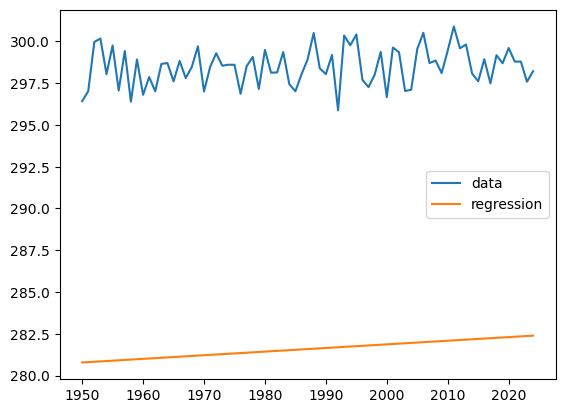

In [17]:
plt.plot(ds_max.year, buf.t2m.values, label='data')
plt.plot(ds_max.year, buf_trend_slope * ds_max.year.values + buf_trend_intercept, label='regression')
plt.legend()

In [14]:
da = ds_max['t2m'] - ds_mean['t2m']
da 

<xarray.DataArray 't2m' (year: 75, lat: 180, lon: 360)> Size: 19MB
array([[[-19.137177, -19.105087, -19.07396 , ..., -19.220978,
         -19.193085, -19.16571 ],
        [-18.305511, -18.23198 , -18.156448, ..., -18.471573,
         -18.418335, -18.362885],
        [-18.634354, -18.51915 , -18.42543 , ..., -18.970367,
         -18.871887, -18.762604],
        ...,
        [-19.829315, -19.837769, -19.850876, ..., -19.956406,
         -19.912659, -19.866852],
        [-21.02501 , -21.026703, -21.029373, ..., -21.02835 ,
         -21.026917, -21.025787],
        [-22.335144, -22.339767, -22.344223, ..., -22.321686,
         -22.326263, -22.330948]],

       [[-20.549667, -20.521347, -20.48999 , ..., -20.615982,
         -20.593811, -20.571152],
        [-23.115555, -23.1566  , -23.193344, ..., -22.906403,
         -22.979263, -23.049698],
        [-25.470566, -25.417358, -25.383896, ..., -25.36792 ,
         -25.423645, -25.46405 ],
...
        [-18.947495, -18.99913 , -19.05095 , ..., -18.715515,
         -18.795685, -18.874207],
        [-18.192184, -18.2426  , -18.29219 , ..., -18.018875,
         -18.077057, -18.135086],
        [-17.38379 , -17.415909, -17.448196, ..., -17.27478 ,
         -17.311462, -17.348434]],

       [[-15.051224, -15.040176, -15.027695, ..., -15.069504,
         -15.063599, -15.057419],
        [-15.218826, -15.215469, -15.212357, ..., -15.217682,
         -15.219513, -15.219086],
        [-14.856903, -14.832199, -14.821213, ..., -14.879288,
         -14.879501, -14.874527],
        ...,
        [-22.08133 , -22.07193 , -22.063232, ..., -22.036392,
         -22.054474, -22.071152],
        [-21.970078, -21.987823, -22.003937, ..., -21.870132,
         -21.904083, -21.937943],
        [-21.77304 , -21.773758, -21.773605, ..., -21.754456,
         -21.760788, -21.767075]]], dtype=float32)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024

In [20]:
ds_max = ds_max.assign({'t2m_anom': da})
ds_max

<xarray.Dataset> Size: 39MB
Dimensions:   (lat: 180, lon: 360, year: 75)
Coordinates:
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * year      (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m       (year, lat, lon) float32 19MB ...
    t2m_anom  (year, lat, lon) float32 19MB -19.14 -19.11 ... -21.76 -21.77

In [21]:
describe(ds_max['t2m_anom'].values.flatten())

DescribeResult(nobs=4860000, minmax=(-52.8667, -0.6819763), mean=-12.899947, variance=96.95866100258787, skewness=-0.7508420190843363, kurtosis=-0.2546188946458874)

In [258]:
land_mask

<xarray.Dataset> Size: 52MB
Dimensions:    (longitude: 3600, latitude: 1801, time: 1)
Coordinates:
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
  * latitude   (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0
  * time       (time) datetime64[ns] 8B 2013-11-29
Data variables:
    lsm        (time, latitude, longitude) float64 52MB ...
Attributes:
    Conventions:               CF-1.6
    history:                   Fri Jun 12 14:44:03 2020: ncpdq -U lsm_1279l4_...
    NCO:                       4.7.2
    nco_openmp_thread_number:  1

In [259]:
land_mask['latitude'].values

array([ 90. ,  89.9,  89.8, ..., -89.8, -89.9, -90. ], dtype=float32)

In [260]:
lat_mask = (land_mask.latitude >= min(ds_max.lat)) & (land_mask.latitude <= max(ds_max.lat))
lon_mask = (land_mask.longitude >= min(ds_max.lon)) & (land_mask.longitude <= max(ds_max.lon))

In [261]:
lat_mask

<xarray.DataArray (latitude: 1801)> Size: 2kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * latitude  (latitude) float32 7kB 90.0 89.9 89.8 89.7 ... -89.8 -89.9 -90.0

In [262]:
land_mask = land_mask.sel(longitude=lon_mask, latitude=lat_mask).copy()

In [263]:
land_mask

<xarray.Dataset> Size: 51MB
Dimensions:    (longitude: 3591, latitude: 1791, time: 1)
Coordinates:
  * longitude  (longitude) float32 14kB 0.0 0.1 0.2 0.3 ... 358.8 358.9 359.0
  * latitude   (latitude) float32 7kB 89.5 89.4 89.3 89.2 ... -89.3 -89.4 -89.5
  * time       (time) datetime64[ns] 8B 2013-11-29
Data variables:
    lsm        (time, latitude, longitude) float64 51MB ...
Attributes:
    Conventions:               CF-1.6
    history:                   Fri Jun 12 14:44:03 2020: ncpdq -U lsm_1279l4_...
    NCO:                       4.7.2
    nco_openmp_thread_number:  1

In [264]:
ds_output_grid = xr.Dataset(
    {
        'lat': (['lat'], ds_max['lat'].values),
        'lon': (['lon'], ds_max['lon'].values)
    }
)
ds_output_grid

<xarray.Dataset> Size: 4kB
Dimensions:  (lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
Data variables:
    *empty*

In [265]:
regridder = xe.Regridder(land_mask, ds_output_grid, 'conservative')
regridder

xESMF Regridder 
Regridding algorithm:       conservative 
Weight filename:            conservative_1791x3591_180x360.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1791, 3591) 
Output grid shape:          (180, 360) 
Periodic in longitude?      False

In [266]:
land_mask_regridded = regridder(land_mask, keep_attrs=True)
land_mask_regridded

<xarray.Dataset> Size: 523kB
Dimensions:  (time: 1, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 8B 2013-11-29
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) int64 3kB 0 1 2 3 4 5 6 7 ... 352 353 354 355 356 357 358 359
Data variables:
    lsm      (time, lat, lon) float64 518kB 0.4386 0.7975 0.7975 ... 0.0 0.0 0.0
Attributes:
    Conventions:               CF-1.6
    history:                   Fri Jun 12 14:44:03 2020: ncpdq -U lsm_1279l4_...
    NCO:                       4.7.2
    nco_openmp_thread_number:  1
    regrid_method:             conservative

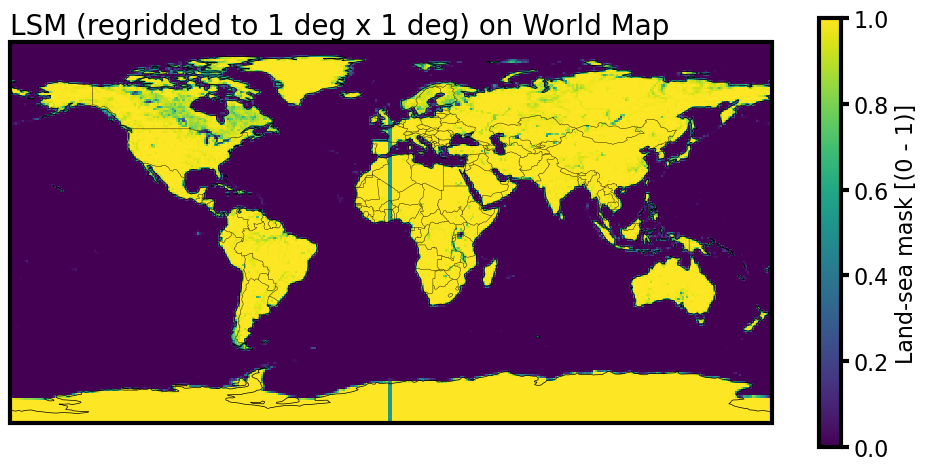

In [267]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data = land_mask_regridded['lsm']

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis")

# Optional title
plt.title(f"LSM (regridded to 1 deg x 1 deg) on World Map")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('land-sea-mask-regridded',
                                     'png', 'figs/'))
plt.show()

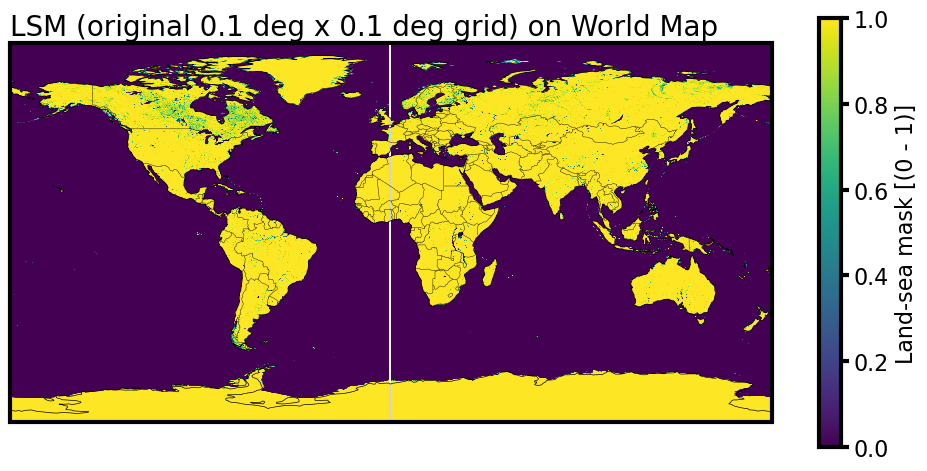

In [268]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

data = land_mask['lsm']

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="viridis")

# Optional title
plt.title(f"LSM (original 0.1 deg x 0.1 deg grid) on World Map")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('land-sea-mask-original',
                                     'png', 'figs/'))
plt.show()

In [269]:
lsm_vals = land_mask_regridded['lsm'].values[0]
lsm_vals = lsm_vals.flatten()

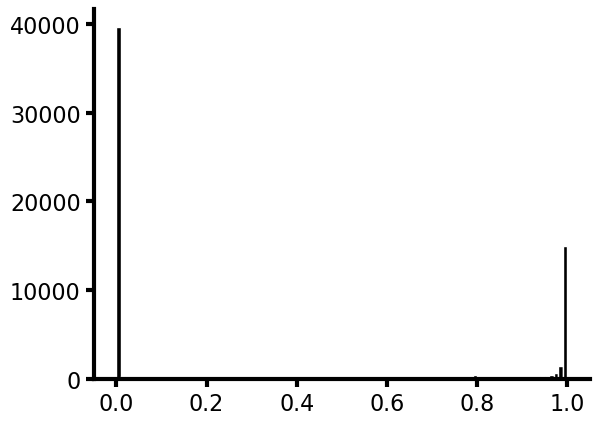

In [270]:
plt.hist(lsm_vals, density=False, bins=100)
plt.show()

I'll now set a threshold for me to consider something as "land". The ERA5 land mask is a float in [0, 1] that gives fractional water/land ratio. Anything above 0.5, though, is definitely not the ocean. But it could be a lake or something. So I'll go with 0.9 to say that, OK, there might be some lake or river sharing this box, but on the whole, it's land.

In [271]:
MASK_THRES = 0.5  # threshold for me to consider something "land"

In [272]:
ds_max_masked = ds_max.where(land_mask_regridded['lsm'].data[0] > MASK_THRES, np.nan)

In [273]:
ds_max_masked.sel(lat=51.509865, lon=360, method='nearest')

<xarray.Dataset> Size: 916B
Dimensions:  (year: 75)
Coordinates:
    lat      float64 8B 51.5
    lon      int64 8B 359
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year) float32 300B 295.5 293.0 297.2 296.3 ... 301.1 296.9 295.9

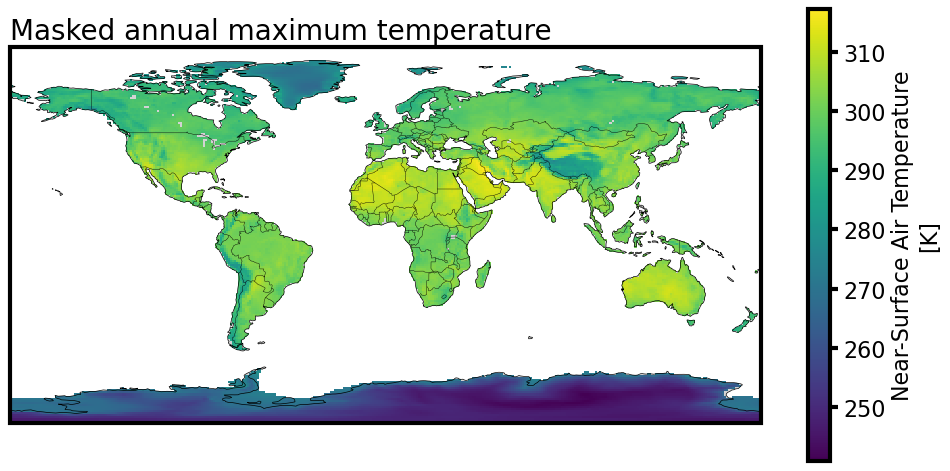

In [274]:
data = ds_max_masked['t2m'].sel(year=2000)

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree())

# Optional title
plt.title(f"Masked annual maximum temperature")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('masked-t',
                                     'png', 'figs/'))
plt.show()

## Algorithm: Figure 1
1. Take the hottest year on record (already done in preprocessing)
2. Fit a GEV to each (lat, lon) pair
3. Compute the Kuiper statistic at each (lat, lon)
4. Aggregate and plot CDF of Kuiper statistic (from obs)
5. Take 75 samples from the fitted GEV distributions
6. Aggregate synthetic data and plot CDF of Kuiper statistic (From synthetics)
7. Plot against reanalysis
8. Hopefully, it'll all be the same.
9. Repeat for each grid size and max/min data.

In [275]:
buff_lat, buff_lon = 42.880230, -78.878738 + 360  # Buffalo, NY

In [276]:
buff = ds_max_masked.sel(lat=buff_lat, lon=buff_lon, method='nearest')

(array([ 1.,  5.,  9.,  8.,  9., 15., 10., 11.,  3.,  4.]),
 array([22.87142944, 23.37322044, 23.87501144, 24.37680435, 24.87859535,
        25.38038635, 25.88217735, 26.38396835, 26.88576126, 27.38755226,
        27.88934326]),
 <BarContainer object of 10 artists>)

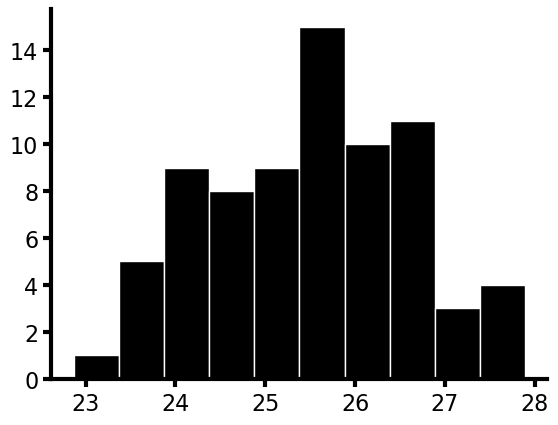

In [277]:
plt.hist(buff['t2m'] - 273)

In [278]:
def _gev_helper(values):
    c, loc, scale = genextreme.fit(values)
    return np.array([c, loc, scale])

In [279]:
def get_gev_fit_lat_lon(da, fit_dim, parallel=True):
    
    def _gev_helper(values):
        values = values[np.isfinite(values)]
        if len(values) < 10:
            return np.array([np.nan] * 3)
        try:
            c, loc, scale = genextreme.fit(values)
            return np.array([c, loc, scale])
        except Exception:
            return np.array([np.nan] * 3)

    if parallel:
        gev_params = xr.apply_ufunc(
            _gev_helper,
            da,
            input_core_dims=[['year']],
            output_core_dims=[['gev_params']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
        )
    else:
        gev_params = xr.apply_ufunc(
            _gev_helper,
            da,
            input_core_dims=[['year']],
            output_core_dims=[['gev_params']]
        )

    #gev_params = gev_params.assign_coords(gev_param=['shape', 'location', 'scale'])
    #gev_ds = gev_params.to_dataset(dim='gev_params')

    return gev_params

In [227]:
da_max_m = ds_max_masked['t2m']

In [228]:
da_max_m

<xarray.DataArray 't2m' (year: 75, lat: 360, lon: 720)> Size: 78MB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan, 252.37877, 252.36346, ..., 252.44246, 252.42609,
         252.40996],
        [      nan, 251.9708 , 251.96005, ..., 252.0089 , 251.99992,
         251.99088],
        [      nan, 251.39214, 251.38698, ..., 251.40643, 251.40363,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan, 250.19246, 250.17798, ..., 250.24695, 250.23416,
         250.22075],
        [      nan, 249.935  , 249.93356, ..., 249.93872, 249.9379 ,
         249.93713],
        [      nan, 249.74889, 249.74431, ..., 249.761  , 249.75882,
               nan]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan, 249.25424, 249.23651, ..., 249.33516, 249.31375,
         249.29245],
        [      nan, 249.36404, 249.3518 , ..., 249.41528, 249.40216,
         249.38904],
        [      nan, 249.31726, 249.31134, ..., 249.34074, 249.33484,
               nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 3kB 0.125 0.625 1.125 1.625 ... 358.6 359.1 359.6
  * lat      (lat) float32 1kB 89.88 89.38 88.88 88.38 ... -88.62 -89.12 -89.62
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Attributes:
    long_name:  Near-Surface Air Temperature
    units:      K

In [229]:
gev_fit = get_gev_fit_lat_lon(da_max_m, 'year')

In [230]:
gev_fit.data.T[0].shape

(720, 360)

In [231]:
ds_max_masked = ds_max_masked.assign(shape = (('lat', 'lon'), gev_fit.data[:, :, 0]))
ds_max_masked = ds_max_masked.assign(loc = (('lat', 'lon'), gev_fit.data[:, :, 1]))
ds_max_masked = ds_max_masked.assign(scale = (('lat', 'lon'), gev_fit.data[:, :, 2]))

ds_max_masked

<xarray.Dataset> Size: 84MB
Dimensions:  (year: 75, lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float32 3kB 0.125 0.625 1.125 1.625 ... 358.6 359.1 359.6
  * lat      (lat) float32 1kB 89.88 89.38 88.88 88.38 ... -88.62 -89.12 -89.62
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float32 78MB nan nan nan nan ... 249.3 249.3 nan
    shape    (lat, lon) float64 2MB nan nan nan nan ... 0.07067 0.07059 nan
    loc      (lat, lon) float64 2MB nan nan nan nan ... 250.3 250.3 250.3 nan
    scale    (lat, lon) float64 2MB nan nan nan nan ... 1.882 1.881 1.881 nan

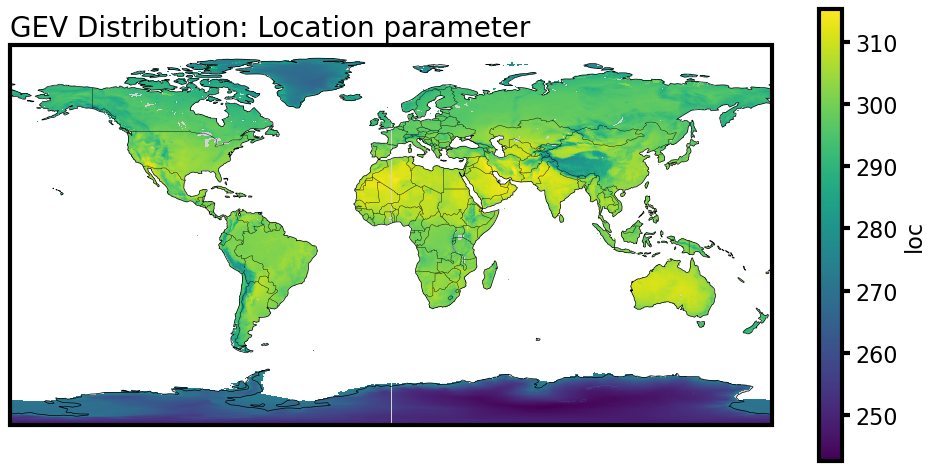

In [232]:
data = ds_max_masked['loc']

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree())

# Optional title
plt.title(f"GEV Distribution: Location parameter")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('loc',
                                     'png', 'figs/'))
plt.show()

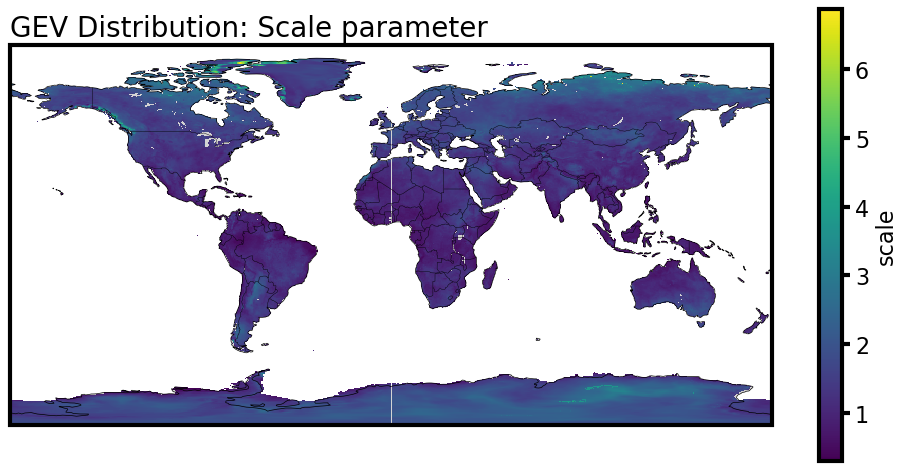

In [233]:
data = ds_max_masked['scale']

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree())

# Optional title
plt.title(f"GEV Distribution: Scale parameter")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('scale',
                                     'png', 'figs/'))
plt.show()

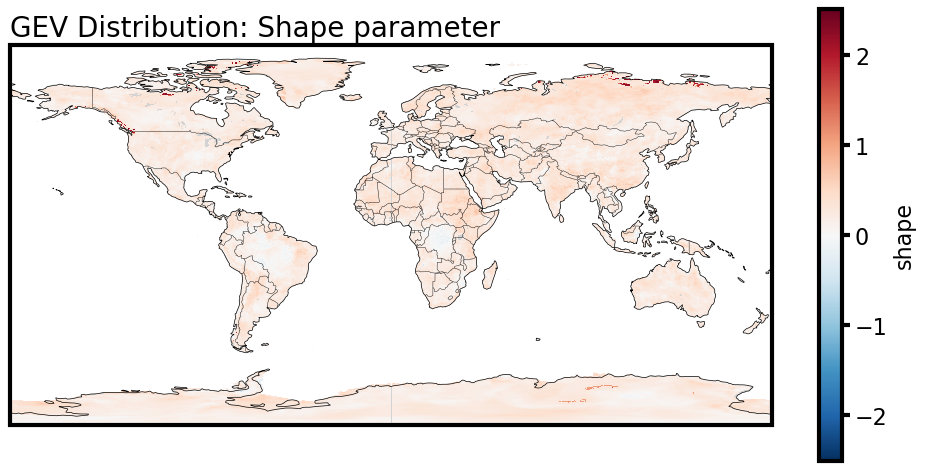

In [234]:
data = ds_max_masked['shape']

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree())

# Optional title
plt.title(f"GEV Distribution: Shape parameter")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('shape',
                                     'png', 'figs/'))
plt.show()

In [235]:
locs = ds_max_masked['scale'].values
locs = locs[np.isfinite(locs)]
describe(locs)

DescribeResult(nobs=87524, minmax=(0.3065109431944507, 6.867922227663545), mean=1.555860385941421, variance=0.28044731948165513, skewness=0.830115184248122, kurtosis=3.1711938033173546)

In [236]:
buff_gev = ds_max_masked.sel(lat=buff_lat, lon=buff_lon, method='nearest')

In [237]:
buff_gev

<xarray.Dataset> Size: 932B
Dimensions:  (year: 75)
Coordinates:
    lon      float32 4B 281.1
    lat      float32 4B 42.88
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year) float32 300B 297.4 298.0 300.6 301.5 ... 298.9 298.5 299.2
    shape    float64 8B 0.3621
    loc      float64 8B 299.1
    scale    float64 8B 1.188

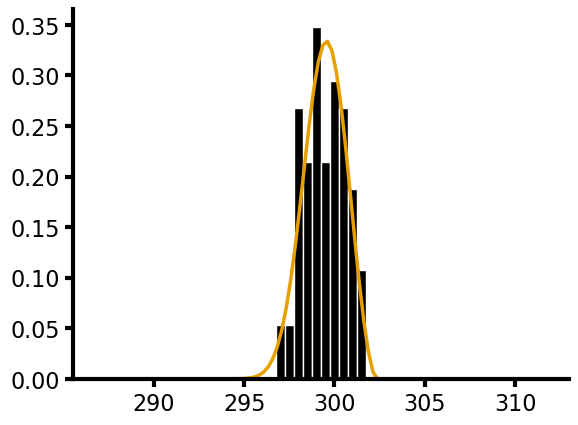

In [238]:
plt.hist(buff_gev['t2m'], density=True)
vals = np.linspace(min(buff_gev['t2m'])-10, max(buff_gev['t2m'])+10, 100)
plt.plot(vals, genextreme.pdf(vals, buff_gev['shape'], buff_gev['loc'], buff_gev['scale']))

In [239]:
ds_max_masked

<xarray.Dataset> Size: 84MB
Dimensions:  (year: 75, lat: 360, lon: 720)
Coordinates:
  * lon      (lon) float32 3kB 0.125 0.625 1.125 1.625 ... 358.6 359.1 359.6
  * lat      (lat) float32 1kB 89.88 89.38 88.88 88.38 ... -88.62 -89.12 -89.62
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float32 78MB nan nan nan nan ... 249.3 249.3 nan
    shape    (lat, lon) float64 2MB nan nan nan nan ... 0.07067 0.07059 nan
    loc      (lat, lon) float64 2MB nan nan nan nan ... 250.3 250.3 250.3 nan
    scale    (lat, lon) float64 2MB nan nan nan nan ... 1.882 1.881 1.881 nan

In [240]:
def _synth_sampler(shape, loc, scale):
    if np.isnan(shape) or np.isnan(loc) or np.isnan(scale):
        return np.full(75, np.nan)
    return genextreme.rvs(shape, loc, scale, size=75)

ds_synth = xr.apply_ufunc(
        _synth_sampler,
        ds_max_masked['shape'],
        ds_max_masked['loc'],
        ds_max_masked['scale'],
        input_core_dims=[[], [], []],
        output_core_dims=[['samples']],
        vectorize=True,
        dask='parallelize',
        output_dtypes=[float]
    )

In [241]:
np.transpose(ds_synth.data, [-1, 0, 1]).shape

(75, 360, 720)

In [242]:
ds_max_masked = ds_max_masked.assign(synth_t2m = (('year', 'lat', 'lon'), np.transpose(ds_synth.data, [-1, 0, 1])))

In [243]:
ds_max_masked

<xarray.Dataset> Size: 240MB
Dimensions:    (year: 75, lat: 360, lon: 720)
Coordinates:
  * lon        (lon) float32 3kB 0.125 0.625 1.125 1.625 ... 358.6 359.1 359.6
  * lat        (lat) float32 1kB 89.88 89.38 88.88 ... -88.62 -89.12 -89.62
  * year       (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m        (year, lat, lon) float32 78MB nan nan nan nan ... 249.3 249.3 nan
    shape      (lat, lon) float64 2MB nan nan nan nan ... 0.07067 0.07059 nan
    loc        (lat, lon) float64 2MB nan nan nan nan ... 250.3 250.3 250.3 nan
    scale      (lat, lon) float64 2MB nan nan nan nan ... 1.882 1.881 1.881 nan
    synth_t2m  (year, lat, lon) float64 156MB nan nan nan ... 251.1 247.1 nan

In [244]:
b = ds_max_masked.sel(lat=buff_lat, lon=buff_lon, method='nearest')

In [245]:
bt2m = b['t2m']
bshape = b['shape']
bloc = b['loc']
bscale = b['scale']

In [246]:
k, _ = kuiper(bt2m, lambda x: genextreme.cdf(x,
                            c=bshape, loc=bloc, scale=bscale))

In [247]:
k

0.16472450627625246

In [248]:
def _kuiper(sample, shape, loc, scale):
    sample = sample[np.isfinite(sample)]

    if len(sample) < 10:
        return np.array([-1])

    else:
        k, _ = kuiper(sample,
                           lambda x: genextreme.cdf(x,
                                                c=shape, loc=loc, scale=scale))
        return np.array([k]) 

da_k = xr.apply_ufunc(
    _kuiper,
    ds_max_masked['t2m'],
    ds_max_masked['shape'],
    ds_max_masked['loc'],
    ds_max_masked['scale'],
    input_core_dims=[['year'], [], [], []],
    output_core_dims=[['kuiper']],
    vectorize=True,
    dask='parallelize',
    output_dtypes=[float]
)

da_ks = xr.apply_ufunc(
    _kuiper,
    ds_max_masked['synth_t2m'],
    ds_max_masked['shape'],
    ds_max_masked['loc'],
    ds_max_masked['scale'],
    input_core_dims=[['year'], [], [], []],
    output_core_dims=[['kuiper']],
    vectorize=True,
    dask='parallelize',
    output_dtypes=[float]
)

In [249]:
ds_max_masked = ds_max_masked.assign(obs_k = (('lat', 'lon'), da_k.data[:, :, 0]))
ds_max_masked = ds_max_masked.assign(syn_k = (('lat', 'lon'), da_ks.data[:, :, 0]))

In [250]:
ds_max_masked

<xarray.Dataset> Size: 244MB
Dimensions:    (year: 75, lat: 360, lon: 720)
Coordinates:
  * lon        (lon) float32 3kB 0.125 0.625 1.125 1.625 ... 358.6 359.1 359.6
  * lat        (lat) float32 1kB 89.88 89.38 88.88 ... -88.62 -89.12 -89.62
  * year       (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
Data variables:
    t2m        (year, lat, lon) float32 78MB nan nan nan nan ... 249.3 249.3 nan
    shape      (lat, lon) float64 2MB nan nan nan nan ... 0.07067 0.07059 nan
    loc        (lat, lon) float64 2MB nan nan nan nan ... 250.3 250.3 250.3 nan
    scale      (lat, lon) float64 2MB nan nan nan nan ... 1.882 1.881 1.881 nan
    synth_t2m  (year, lat, lon) float64 156MB nan nan nan ... 251.1 247.1 nan
    obs_k      (lat, lon) float64 2MB -1.0 -1.0 -1.0 -1.0 ... 0.1139 0.1131 -1.0
    syn_k      (lat, lon) float64 2MB -1.0 -1.0 -1.0 -1.0 ... 0.1446 0.1126 -1.0

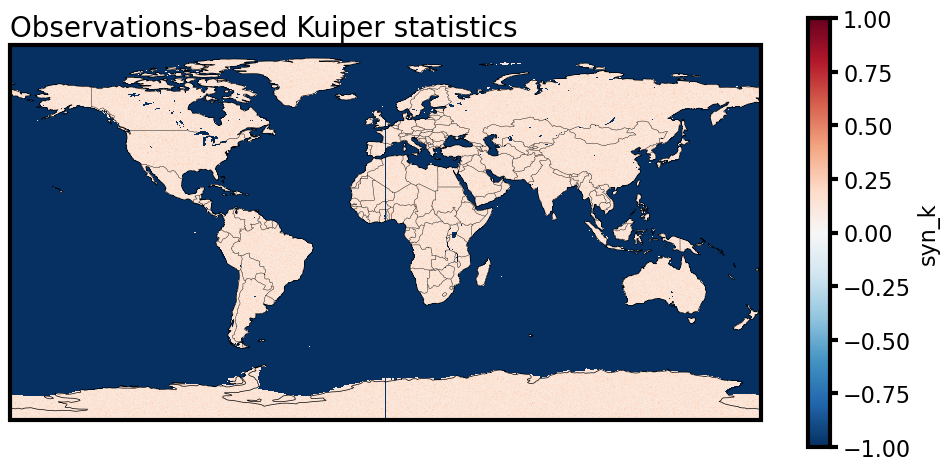

In [251]:
data = ds_max_masked['syn_k']

# --- Create the map ---
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# --- Plot data ---
# If you have 2D lat/lon grid
data.plot(ax=ax, transform=ccrs.PlateCarree())

# Optional title
plt.title(f"Observations-based Kuiper statistics")

# Show or save
plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('kuiper',
                                     'png', 'figs/'))
plt.show()

In [252]:
obs_k = ds_max_masked['obs_k'].values.flatten()
syn_k = ds_max_masked['syn_k'].values.flatten()

# ignore nan values (ocean)
obs_k = obs_k[obs_k >= 0.0]
syn_k = syn_k[syn_k >= 0.0]

In [256]:
describe(obs_k), describe(syn_k)

(DescribeResult(nobs=87524, minmax=(0.058051190375751016, 0.850224542853386), mean=0.12724063610293435, variance=0.0019733514886860273, skewness=8.127749083206348, kurtosis=105.70902455608022),
 DescribeResult(nobs=87524, minmax=(0.05664963497339175, 0.3226178586353765), mean=0.14030757362828783, variance=0.0009711696514201687, skewness=0.5990887214777677, kurtosis=0.3600410402851342))

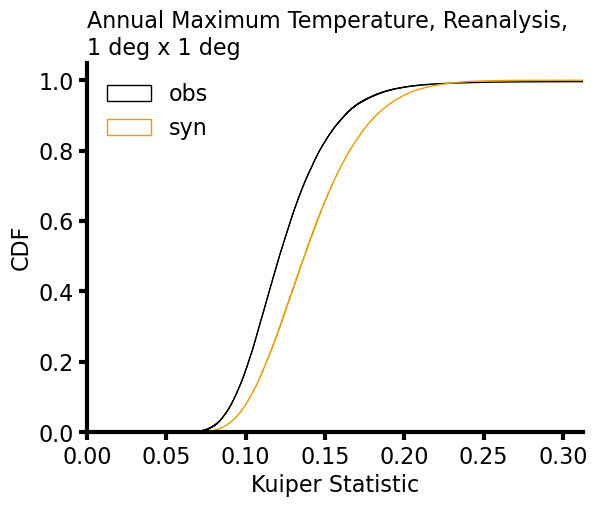

In [255]:
fig, ax = plt.subplots()

ax.hist(obs_k, density=True, cumulative=1, bins=10000, histtype='step', label='obs')
ax.hist(syn_k, density=True, cumulative=1, bins=10000, histtype='step', label='syn')
ax.legend()
ax.set_xlim((0, max(syn_k) - 0.01))
ax.set_xlabel("Kuiper Statistic")
ax.set_ylabel("CDF")
ax.set_title("Annual Maximum Temperature, Reanalysis,\n1 deg x 1 deg", fontsize=16)
if save_figs:
    fig.savefig(make_figure_filename('kuiper-t2m-1deg',
                                     'png', 'figs/'))
    print("Figure saved!")

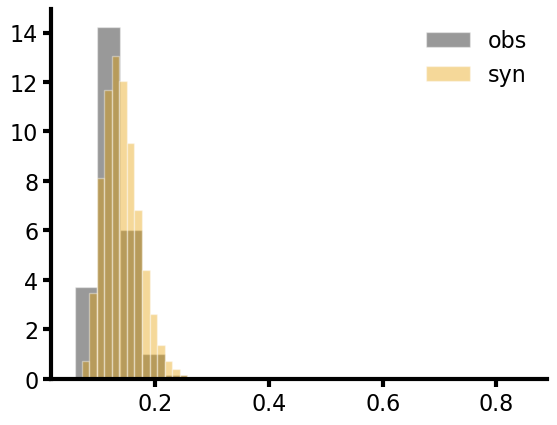

In [254]:
plt.hist(obs_k, density=True, bins=20, alpha=0.4, label='obs')
plt.hist(syn_k, density=True, bins=20, alpha=0.4, label='syn')
plt.legend()

## Algorithm: Figure 2
1. Fit time-varying GEV to the reanalysis (max/min)
2. Plot (`cartopy` or other equivalent) spatial map of GEV parameter trends

## Algorithm: Figure 3
1. Same as Figure 2, but for CMIP6 models.

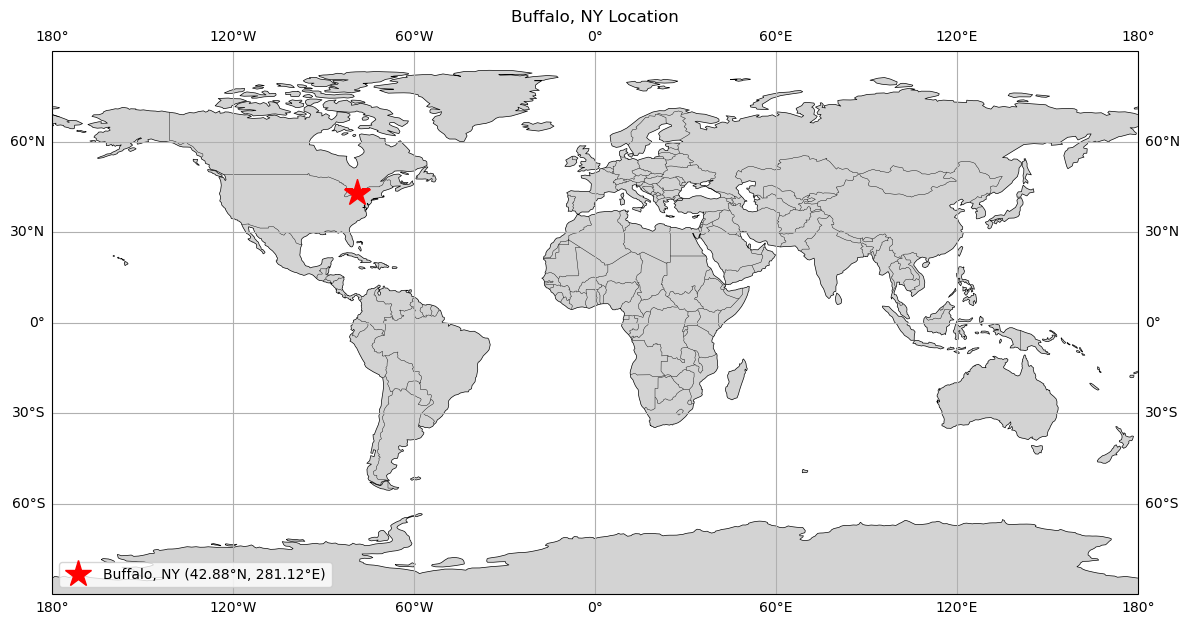

In [10]:
# Plot the Buffalo point on a cartopy map
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define Buffalo coordinates
buff_lat, buff_lon = 42.880230, -78.878738 + 360

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")

# Add gridlines
ax.gridlines(draw_labels=True)

# Plot the Buffalo point
ax.plot(buff_lon, buff_lat, 'r*', markersize=20, transform=ccrs.PlateCarree(), 
        label=f'Buffalo, NY ({buff_lat:.2f}°N, {buff_lon:.2f}°E)')

# Set global extent
ax.set_global()

# Add title and legend
plt.title("Buffalo, NY Location")
plt.legend(loc='lower left')

plt.tight_layout()
if save_figs:
    plt.savefig(make_figure_filename('buffalo-location', 'png', 'figs/'))
plt.show()